In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv('Crop_Recommendation.csv')

### dataset acquaintance

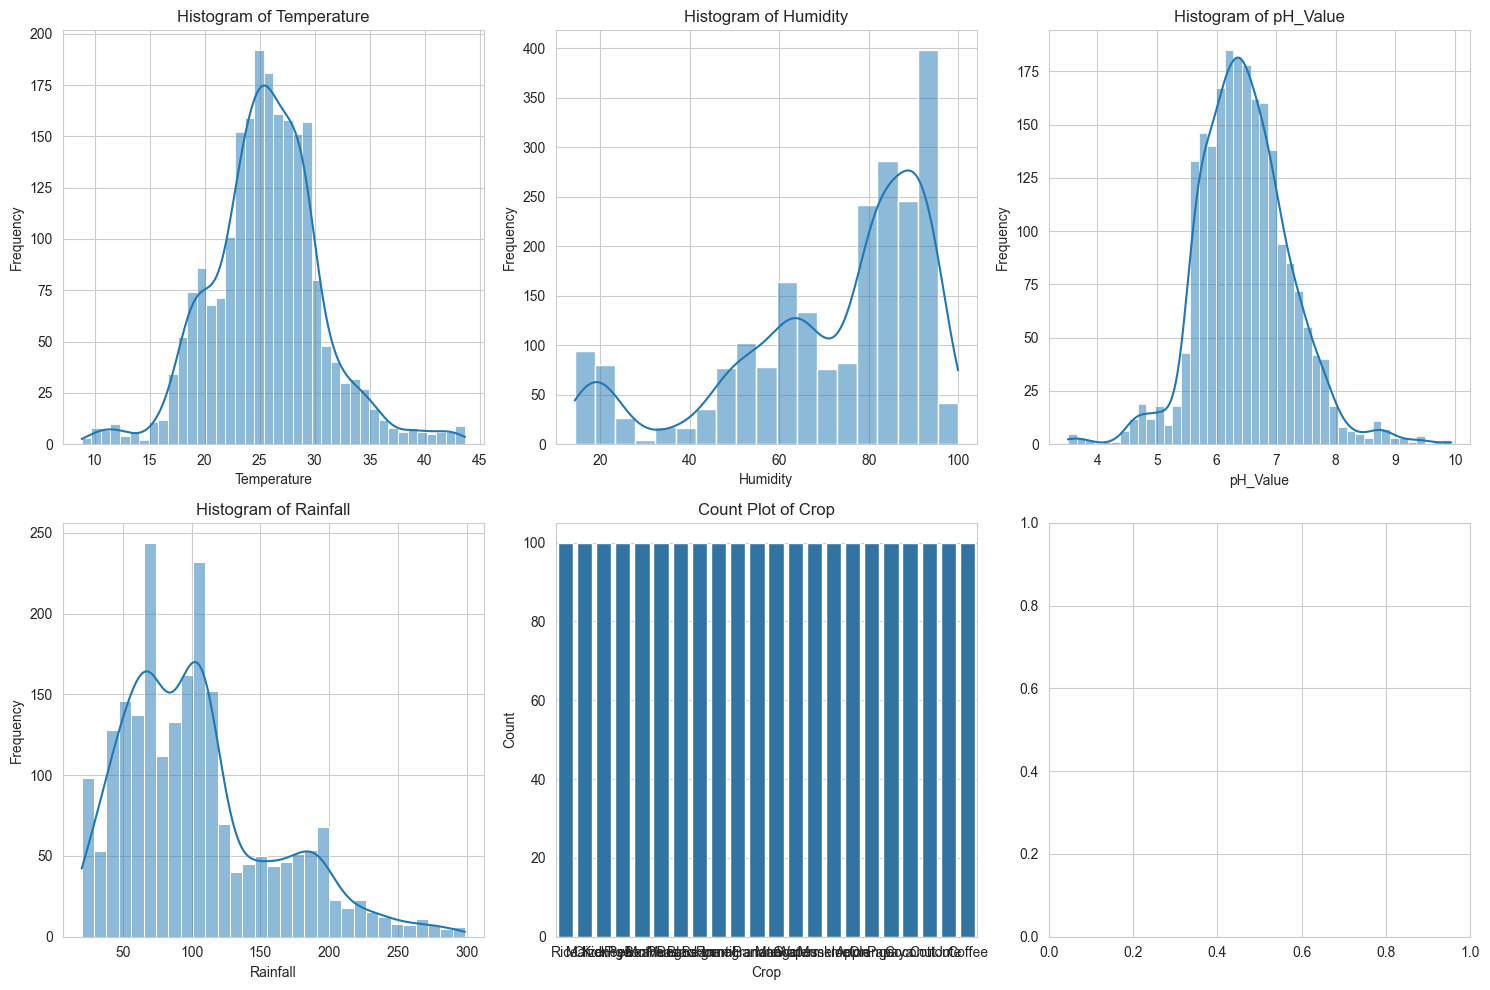

In [14]:
# Set the style of the plots
sns.set_style("whitegrid")
# List of features to plot
features = df.columns[3:]  # Exclude the first column (ID)
# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through each feature and create a plot
for i, feature in enumerate(features):
    if df[feature].dtype == 'object':  # Categorical feature
        sns.countplot(x=feature, data=df, ax=axes[i])
        axes[i].set_title(f'Count Plot of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')
    else:  # Numerical feature
        sns.histplot(df[feature], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
# Adjust layout
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Features')

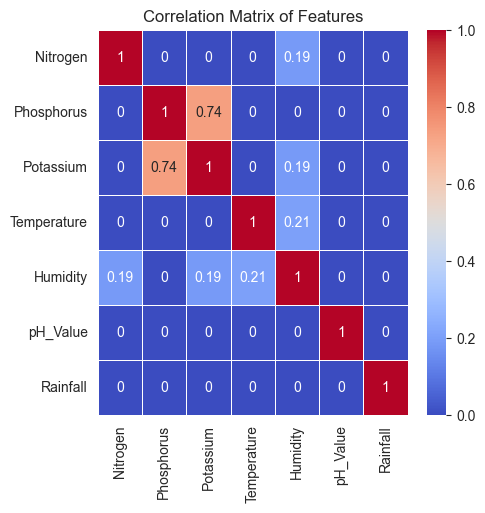

In [17]:
#linear correlation between features
#select features that are numerical for correlation matrix
features = df.select_dtypes(include=[np.number]).columns.tolist()

#how much are columns related? (we truncate above 0.1 to make it more readable)
correlation_matrix = df[features].corr()
correlation_matrix[correlation_matrix < 0.1] = 0
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')

In [21]:
df[["Crop"]].value_counts()

Crop       
Apple          100
Banana         100
Blackgram      100
ChickPea       100
Coconut        100
Coffee         100
Cotton         100
Grapes         100
Jute           100
KidneyBeans    100
Lentil         100
Maize          100
Mango          100
MothBeans      100
MungBean       100
Muskmelon      100
Orange         100
Papaya         100
PigeonPeas     100
Pomegranate    100
Rice           100
Watermelon     100
Name: count, dtype: int64

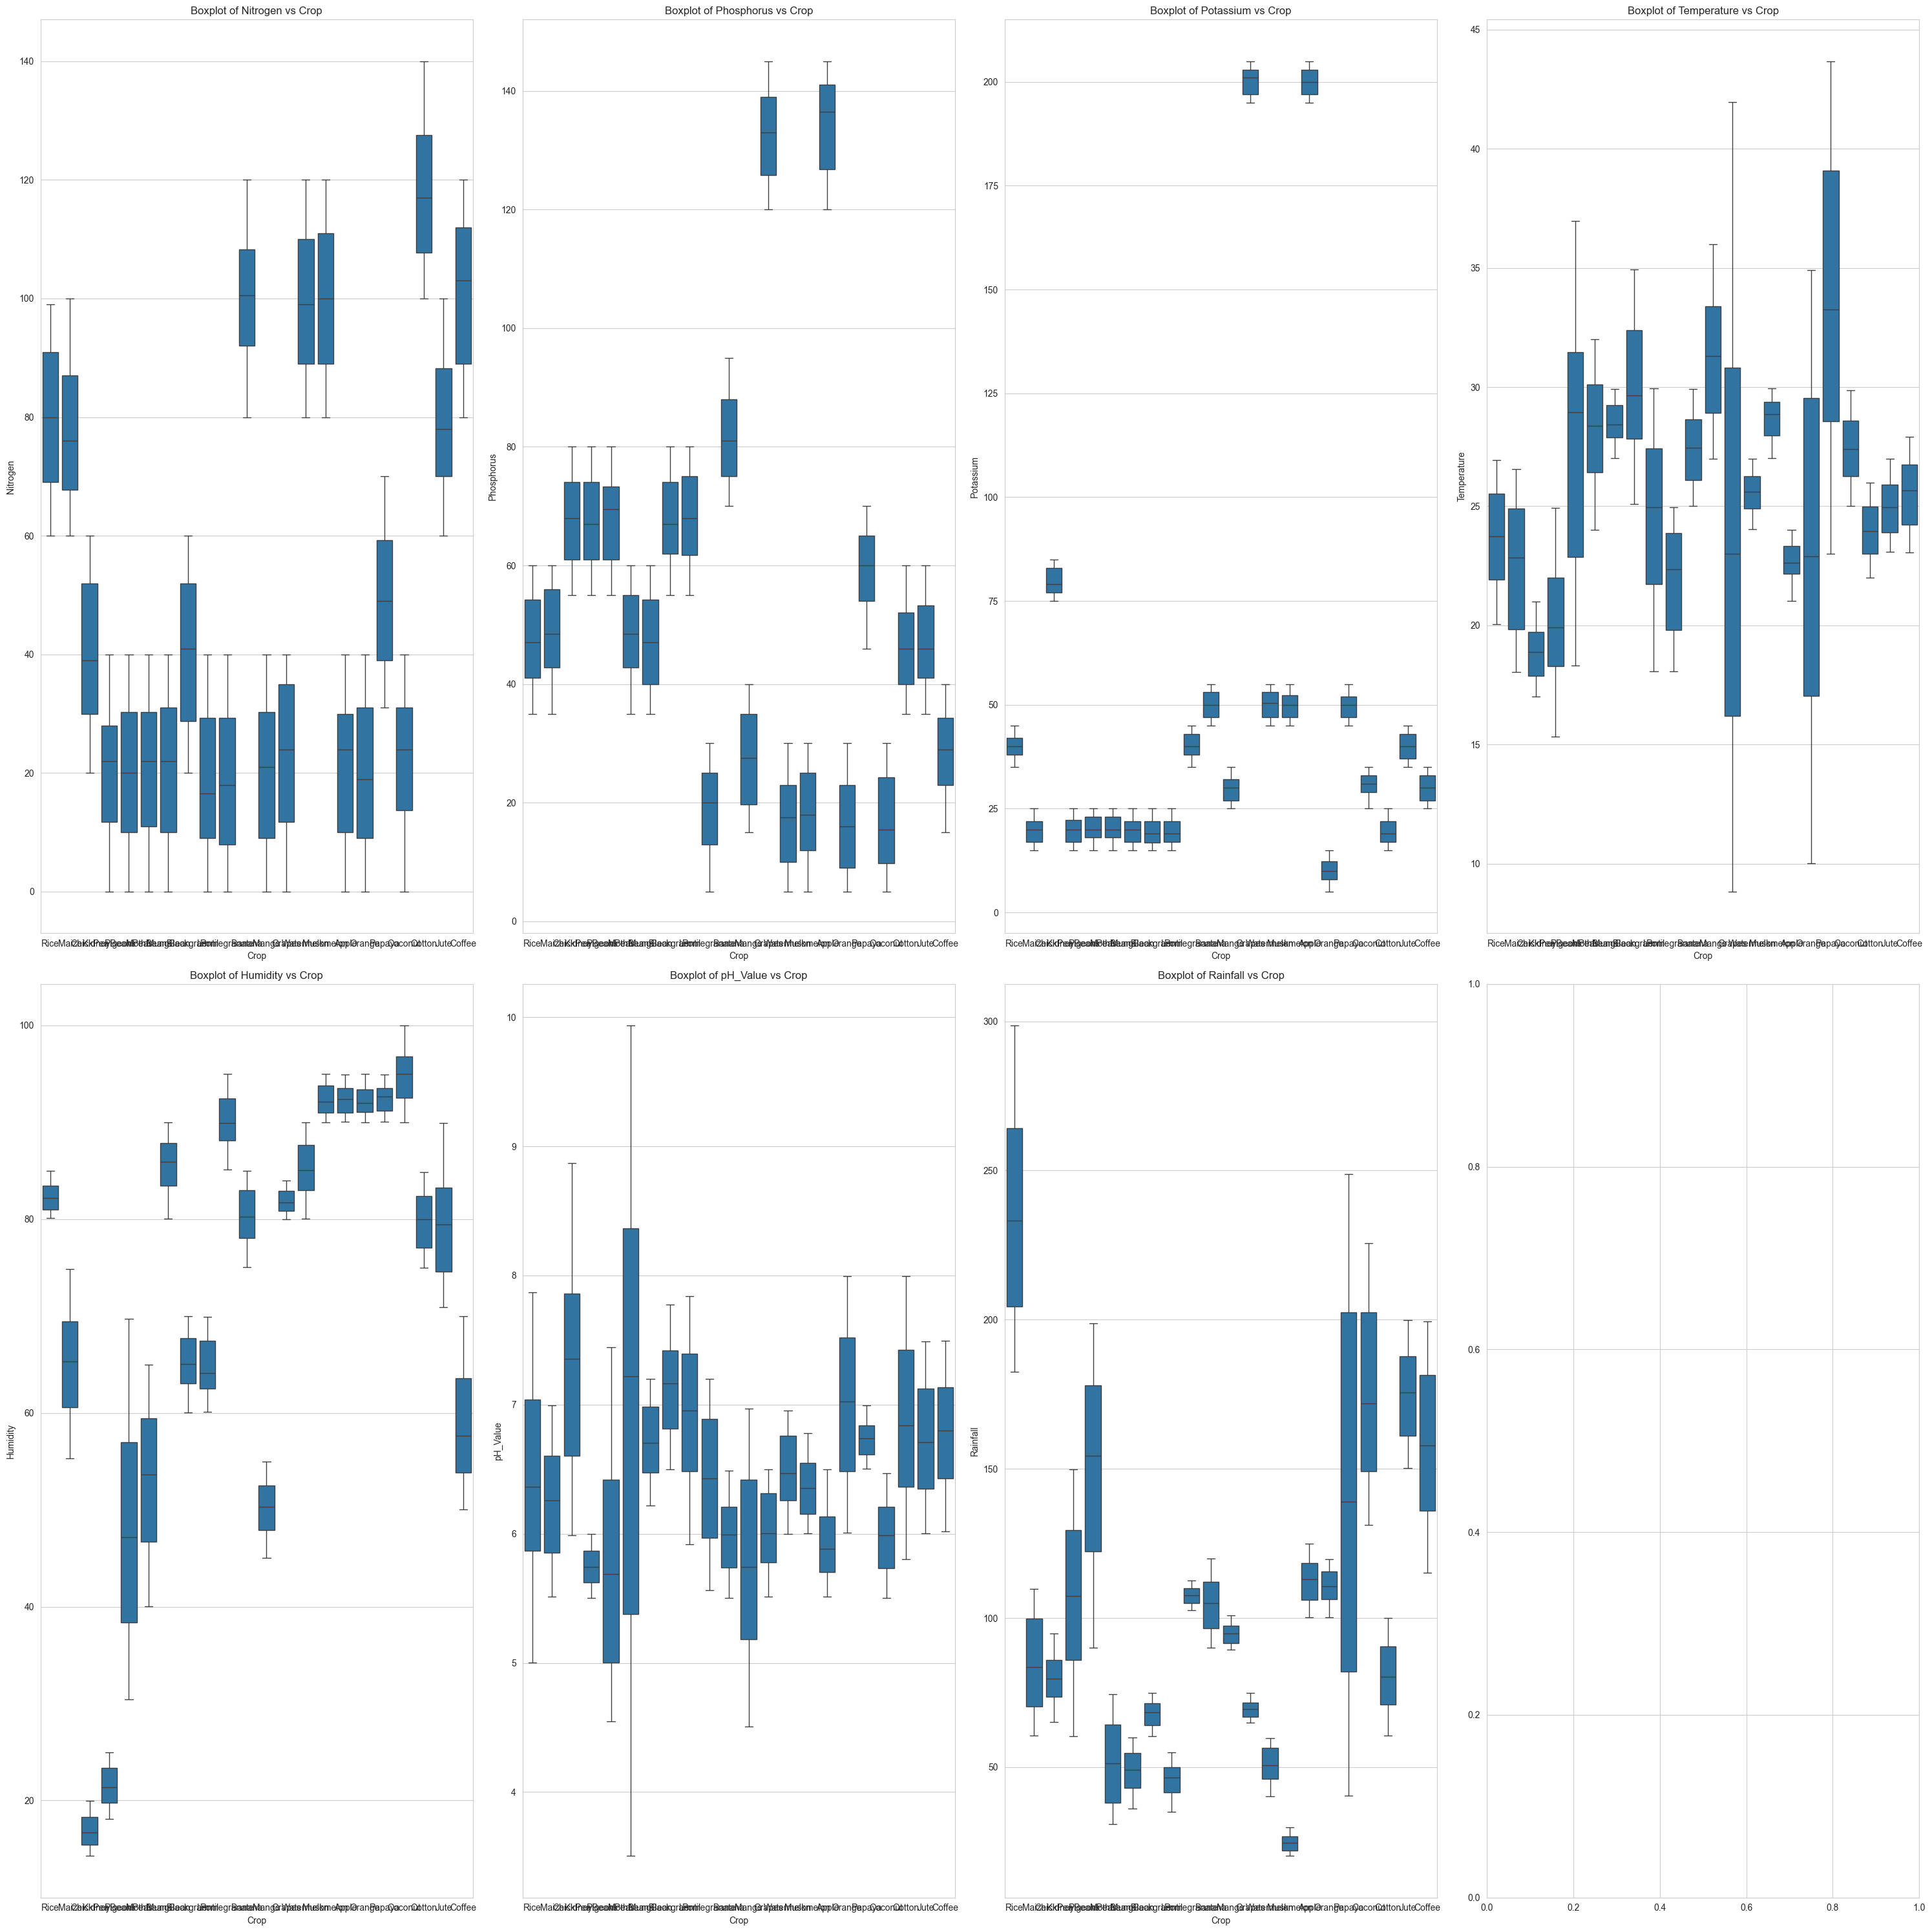

In [20]:
# We can use boxplots to visualize the relationship between each feature and the target variable
# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 30))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
# Loop through each feature and create a boxplot
for i, feature in enumerate(features):
    sns.boxplot(x="Crop", y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} vs Crop')
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(feature)
# Adjust layout
plt.tight_layout()
plt.show()

### pca

Text(0.5, 1.0, 'PCA of Crop Health Dataset')

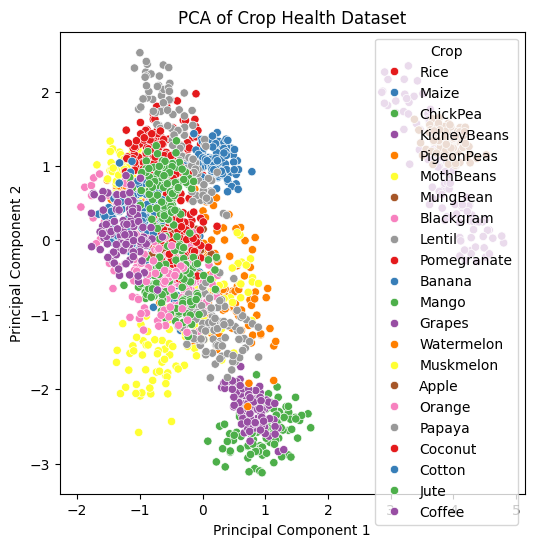

In [5]:
# PCA to visualize the data in 2D
features_pca = df.columns
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_pca[:-1]])  # Exclude the target variable
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Crop'] = df['Crop']
# Visualize the PCA results
plt.figure(figsize=(6, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Crop', data=pca_df, palette='Set1')
plt.title('PCA of Crop Health Dataset')

In [6]:
# get the percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.27588831 0.18484431]


C:\Users\jeanf\AppData\Local\Temp\ipykernel_30096\4158613009.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(crops))


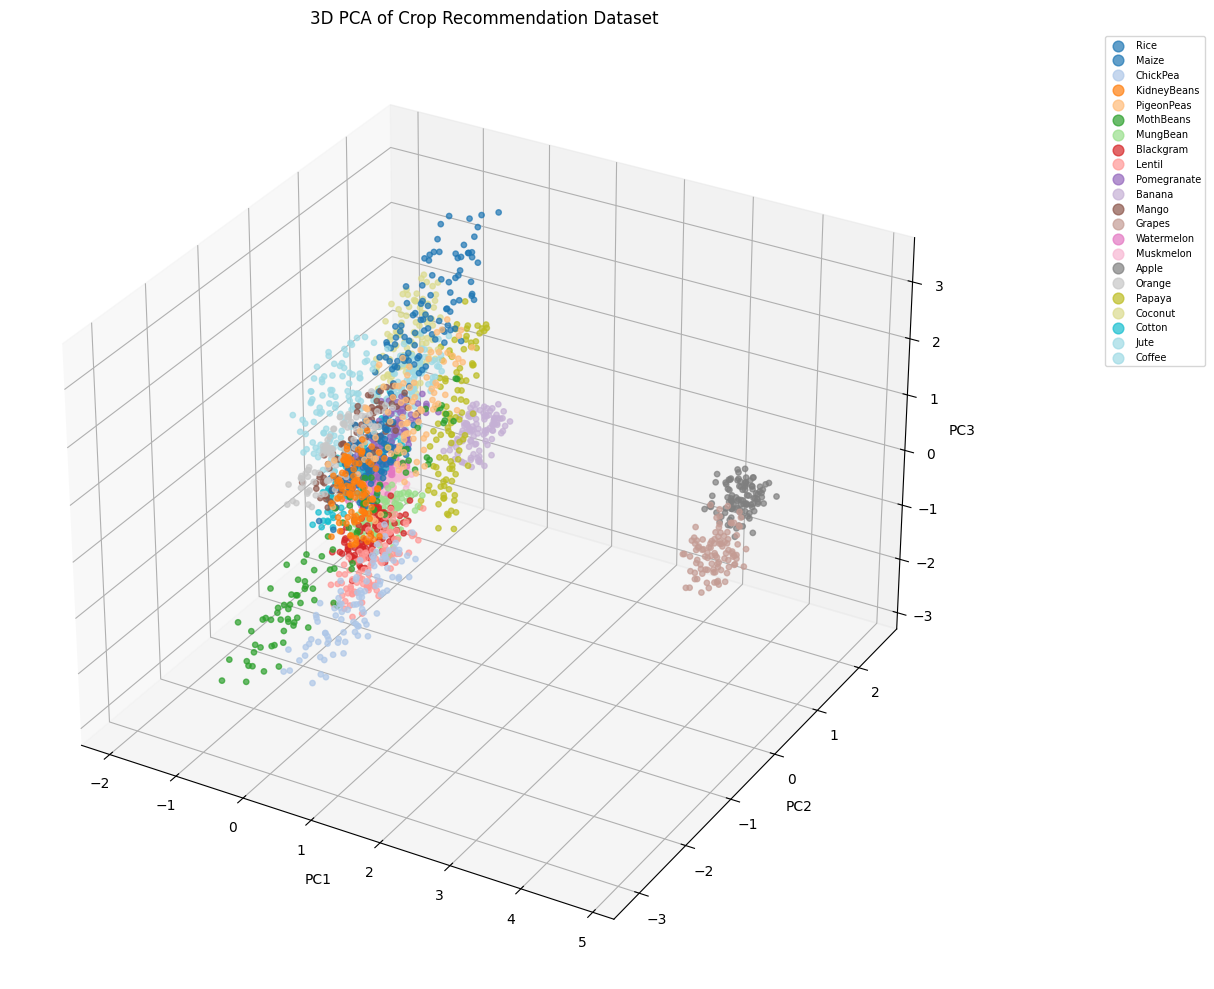

In [9]:
# PCA to visualize the data in 3D

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_pca[:-1]])

pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Crop'] = df['Crop']

# Use a qualitative colormap for distinct crops
crops = pca_df['Crop'].unique()
cmap = plt.cm.get_cmap('tab20', len(crops))
color_map = {crop: cmap(i) for i, crop in enumerate(crops)}
colors = pca_df['Crop'].map(color_map)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for crop in crops:
    mask = pca_df['Crop'] == crop
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], pca_df.loc[mask, 'PC3'],
               label=crop, color=color_map[crop], s=15, alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of Crop Recommendation Dataset')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=7, ncol=1, markerscale=2)
plt.tight_layout()
plt.show()

In [10]:
# get the percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.27588831 0.18484431 0.15378704]


                  PC1       PC2       PC3
Phosphorus   0.643787  0.034358 -0.109939
Potassium    0.622607  0.283829 -0.163173
Humidity    -0.068483  0.737917 -0.213599
Rainfall    -0.072532  0.290158  0.735267
Temperature -0.212428  0.359487 -0.248228
pH_Value    -0.226943 -0.220657 -0.548520
Nitrogen    -0.302191  0.334107 -0.112045


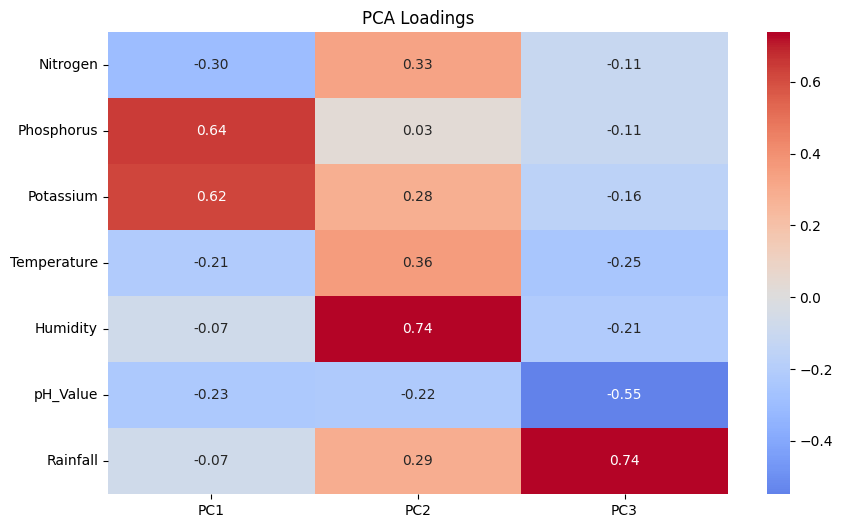

In [11]:
loadings = pd.DataFrame(pca.components_.T, index=features_pca[:-1], columns=['PC1', 'PC2', 'PC3'])
print(loadings.sort_values('PC1', ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('PCA Loadings')
plt.show()

### random forest

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df[['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']]
y = df['Crop']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya       1.00    

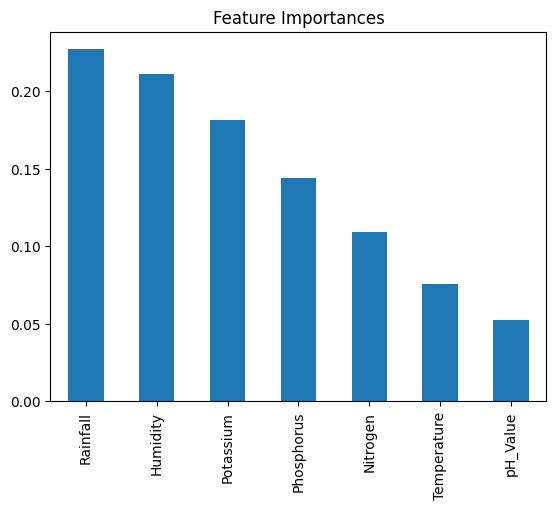

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature Importances')
plt.show()

In [16]:
# other models

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Pour XGBoost il faut encoder les labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

for name, model in models.items():
    target = y_encoded if name == 'XGBoost' else y
    scores = cross_val_score(model, scaler.fit_transform(X), target, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

RandomForest: 0.9945 (+/- 0.0023)
SVM: 0.9845 (+/- 0.0030)
KNN: 0.9714 (+/- 0.0059)


C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [15:51:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [15:51:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [15:51:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } 

XGBoost: 0.9932 (+/- 0.0038)


In [18]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_scaled, y, y_encoded, test_size=0.2, random_state=42
)

models = {
    'RandomForest': (RandomForestClassifier(n_estimators=200, random_state=42), y_train, y_test),
    'SVM': (SVC(kernel='rbf', C=10, gamma='scale'), y_train, y_test),
    'KNN': (KNeighborsClassifier(n_neighbors=5), y_train, y_test),
    'XGBoost': (XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='mlogloss'), y_train_enc, y_test_enc),
}

for name, (model, yt, yte) in models.items():
    model.fit(X_train, yt)
    y_pred = model.predict(X_test)
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(yte, y_pred, target_names=le.classes_ if name == 'XGBoost' else None))


==================== RandomForest ====================
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00  

C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:00:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==================== XGBoost ====================
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       0.95      1.00      0.98        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       0.94      1.00      0.97        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      0.96      0.94        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      0.95      0.98        21
       Mango       0.95      1.00      0.97        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1